In [1]:
import warnings
warnings.filterwarnings("ignore", module=r"matplotlib\..*")

In [7]:
# Učitavanje movie.csv 
import os
import numpy as np
import pandas as pd



relpath = '..\\data\\movie.csv'
abspath = os.path.abspath(relpath)

try:
    df = pd.read_csv(relpath)
except FileNotFoundError:
    df = pd.read_csv(abspath)

print("Dataset učitan:", df.shape)
df.head()

Dataset učitan: (40000, 2)


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


## Ucitavanje podataka

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df.describe()


,label
count,40000.000000
mean,0.499525
std,0.500006
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:

import pandas as pd
from sklearn.model_selection import train_test_split


# Drop missing / empty text
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].notna() & (df["text"] != "")]

# Normalize labels to 0/1
label_map = {
    "positive": 1, "pos": 1, "1": 1, 1: 1, True: 1,
    "negative": 0, "neg": 0, "0": 0, 0: 0, False: 0
}
df["label"] = df["label"].astype(str).str.strip().str.lower().map(label_map)

# Remove rows with unknown labels
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

# Remove duplicates
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Quick checks
print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))

# Stratified split: train/val/test = 70/15/15
X_temp, X_test, y_temp, y_test = train_test_split(
    df["text"], df["label"], test_size=0.15, random_state=42, stratify=df["label"]
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)  # 0.1765 of 85% ~= 15%

print("\nSplit sizes:")
print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

Shape: (39723, 2)

Class distribution:
label
1    0.501171
0    0.498829
Name: ratio, dtype: float64

Split sizes:
Train: 27804
Val:   5960
Test:  5959


In [ ]:
#%pip install -q tensorflow

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Hyperparameters
VOCAB_SIZE = 20000
MAX_LEN = 200
OOV_TOKEN = "<OOV>"

# Keras Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

# Convert text -> sequences
train_seq = tokenizer.texts_to_sequences(X_train)
val_seq   = tokenizer.texts_to_sequences(X_val)
test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

y_train_np = np.array(y_train)
y_val_np   = np.array(y_val)
y_test_np  = np.array(y_test)

print("Train padded shape:", X_train_pad.shape)
print("Val padded shape:", X_val_pad.shape)
print("Test padded shape:", X_test_pad.shape)


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Train padded shape: (27804, 200)
Val padded shape: (5960, 200)
Test padded shape: (5959, 200)


In [12]:
from tensorflow.keras import layers, callbacks, models
from sklearn.utils.class_weight import compute_class_weight

# Optional class weights (useful if classes are imbalanced)
classes = np.unique(y_train_np)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_np)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)

model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train_np,
    validation_data=(X_val_pad, y_val_np),
    epochs=12,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {0: 1.0023794073112697, 1: 0.9976318622174382}
Epoch 1/12


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


435/435 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.7724 - loss: 0.4710 - precision: 0.7729 - recall: 0.7729 - val_accuracy: 0.8622 - val_loss: 0.3349 - val_precision: 0.8494 - val_recall: 0.8815
Epoch 2/12
435/435 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9015 - loss: 0.2595 - precision: 0.8995 - recall: 0.9044 - val_accuracy: 0.8597 - val_loss: 0.4054 - val_precision: 0.8457 - val_recall: 0.8808
Epoch 3/12
435/435 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9288 - loss: 0.1982 - precision: 0.9304 - recall: 0.9273 - val_accuracy: 0.8471 - val_loss: 0.4510 - val_precision: 0.9058 - val_recall: 0.7757
Epoch 4/12
435/435 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9443 - loss: 0.1631 - precision: 0.9473 - recall: 0.9412 - val_accuracy: 0.8319 - val_loss: 0.4974 - val_precision: 0.7696 - val_recall: 0.9484


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test_pad, y_test_np, verbose=0)
y_prob = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test F1:        {f1_score(y_test_np, y_pred):.4f}")

print("\nClassification report:")
print(classification_report(y_test_np, y_pred, digits=4))

print("Confusion matrix:")
print(confusion_matrix(y_test_np, y_pred))

Test Accuracy:  0.8574
Test Precision: 0.8408
Test Recall:    0.8825
Test F1:        0.8611

Classification report:
              precision    recall  f1-score   support

           0     0.8758    0.8322    0.8534      2973
           1     0.8408    0.8825    0.8611      2986

    accuracy                         0.8574      5959
   macro avg     0.8583    0.8573    0.8573      5959
weighted avg     0.8582    0.8574    0.8573      5959

Confusion matrix:
[[2474  499]
 [ 351 2635]]


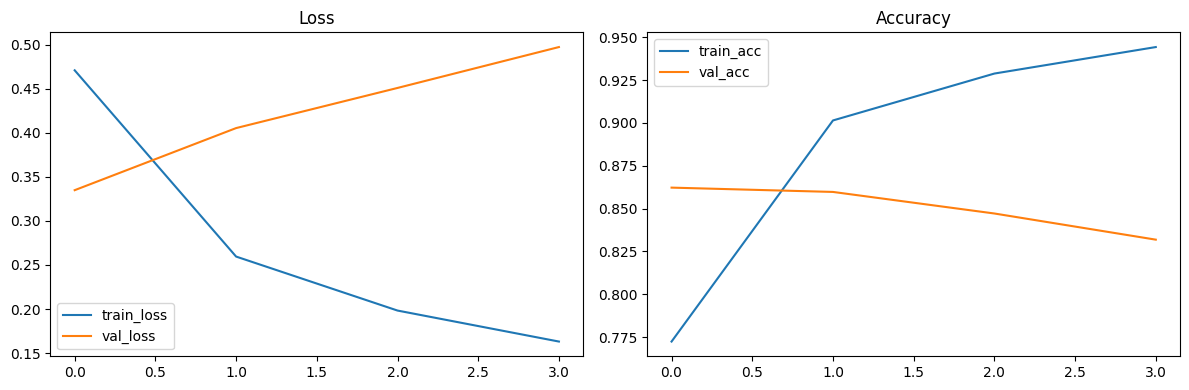

In [14]:
import matplotlib.pyplot as plt

# history from model.fit(...)
hist = history.history

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist["accuracy"], label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve, classification_report, confusion_matrix

# Validation probabilities
val_prob = model.predict(X_val_pad, verbose=0).ravel()

# Search threshold that maximizes F1 on validation
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for t in thresholds:
    val_pred_t = (val_prob >= t).astype(int)
    f1_scores.append(f1_score(y_val_np, val_pred_t))

best_idx = int(np.argmax(f1_scores))
best_t = float(thresholds[best_idx])
best_f1 = float(f1_scores[best_idx])

print(f"Best threshold (val): {best_t:.3f}")
print(f"Best val F1:          {best_f1:.4f}")

Best threshold (val): 0.380
Best val F1:          0.8663


In [16]:
# Final test evaluation with tuned threshold
test_prob = model.predict(X_test_pad, verbose=0).ravel()
test_pred_tuned = (test_prob >= best_t).astype(int)

print(classification_report(y_test_np, test_pred_tuned, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test_np, test_pred_tuned))

              precision    recall  f1-score   support

           0     0.9020    0.7891    0.8418      2973
           1     0.8133    0.9146    0.8610      2986

    accuracy                         0.8520      5959
   macro avg     0.8576    0.8519    0.8514      5959
weighted avg     0.8575    0.8520    0.8514      5959

Confusion matrix:
 [[2346  627]
 [ 255 2731]]


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import f1_score

tf.random.set_seed(42)
np.random.seed(42)

def build_bigru(vocab_size, max_len, emb_dim=128, gru_units=64, drop=0.4, lr=1e-3):
    model = models.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, input_length=max_len),
        layers.Bidirectional(layers.GRU(gru_units)),
        layers.Dropout(drop),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

configs = [
    {"emb_dim": 128, "gru_units": 64,  "drop": 0.4, "lr": 1e-3, "batch_size": 64},
    {"emb_dim": 128, "gru_units": 128, "drop": 0.4, "lr": 1e-3, "batch_size": 64},
    {"emb_dim": 256, "gru_units": 64,  "drop": 0.5, "lr": 5e-4, "batch_size": 64},
]

best = {"f1": -1, "cfg": None, "model": None, "thr": 0.5}

for i, cfg in enumerate(configs, 1):
    print(f"\n=== Config {i}/{len(configs)}: {cfg} ===")
    m = build_bigru(VOCAB_SIZE, MAX_LEN, **{k: cfg[k] for k in ["emb_dim", "gru_units", "drop", "lr"]})
    es = callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

    m.fit(
        X_train_pad, y_train_np,
        validation_data=(X_val_pad, y_val_np),
        epochs=8,
        batch_size=cfg["batch_size"],
        class_weight=class_weight,
        callbacks=[es],
        verbose=0
    )

    val_prob = m.predict(X_val_pad, verbose=0).ravel()
    thrs = np.linspace(0.2, 0.8, 61)
    f1s = [f1_score(y_val_np, (val_prob >= t).astype(int)) for t in thrs]
    idx = int(np.argmax(f1s))
    f1_best = float(f1s[idx])
    thr_best = float(thrs[idx])

    print(f"Val best F1={f1_best:.4f} at threshold={thr_best:.3f}")

    if f1_best > best["f1"]:
        best = {"f1": f1_best, "cfg": cfg, "model": m, "thr": thr_best}

print("\nBest config:", best["cfg"])
print("Best val F1:", round(best["f1"], 4), "Threshold:", round(best["thr"], 3))
best_model = best["model"]
best_t = best["thr"]


=== Config 1/3: {'emb_dim': 128, 'gru_units': 64, 'drop': 0.4, 'lr': 0.001, 'batch_size': 64} ===


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Val best F1=0.8715 at threshold=0.450

=== Config 2/3: {'emb_dim': 128, 'gru_units': 128, 'drop': 0.4, 'lr': 0.001, 'batch_size': 64} ===


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Val best F1=0.8769 at threshold=0.200

=== Config 3/3: {'emb_dim': 256, 'gru_units': 64, 'drop': 0.5, 'lr': 0.0005, 'batch_size': 64} ===


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Val best F1=0.8671 at threshold=0.600

Best config: {'emb_dim': 128, 'gru_units': 128, 'drop': 0.4, 'lr': 0.001, 'batch_size': 64}
Best val F1: 0.8769 Threshold: 0.2


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

test_prob = best_model.predict(X_test_pad, verbose=0).ravel()
test_pred = (test_prob >= best_t).astype(int)

print("Test F1:", round(f1_score(y_test_np, test_pred), 4))
print(classification_report(y_test_np, test_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test_np, test_pred))

Test F1: 0.867
              precision    recall  f1-score   support

           0     0.8655    0.8681    0.8668      2973
           1     0.8683    0.8657    0.8670      2986

    accuracy                         0.8669      5959
   macro avg     0.8669    0.8669    0.8669      5959
weighted avg     0.8669    0.8669    0.8669      5959

Confusion matrix:
 [[2581  392]
 [ 401 2585]]


In [19]:
from pathlib import Path
import json

# Create artifact folder
ARTIFACT_DIR = Path("../artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save best model
best_model_path = ARTIFACT_DIR / "sentiment_bigru.keras"
best_model.save(best_model_path)

# Save tokenizer as JSON
tokenizer_json = tokenizer.to_json()
with open(ARTIFACT_DIR / "tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tokenizer_json)

# Save metadata (must match training)
meta = {
    "max_len": MAX_LEN,
    "vocab_size": VOCAB_SIZE,
    "oov_token": OOV_TOKEN,
    "best_threshold": float(best_t),
    "label_map_out": {0: "negative", 1: "positive"}
}
with open(ARTIFACT_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Saved:")
print("-", best_model_path.resolve())
print("-", (ARTIFACT_DIR / "tokenizer.json").resolve())
print("-", (ARTIFACT_DIR / "meta.json").resolve())

Saved:
- C:\Users\jelen\OneDrive\Documents\_Master\Masinsko ucenje\Git\GIT - Anastasija - Projekat\machine-learning\artifacts\sentiment_bigru.keras
- C:\Users\jelen\OneDrive\Documents\_Master\Masinsko ucenje\Git\GIT - Anastasija - Projekat\machine-learning\artifacts\tokenizer.json
- C:\Users\jelen\OneDrive\Documents\_Master\Masinsko ucenje\Git\GIT - Anastasija - Projekat\machine-learning\artifacts\meta.json


In [20]:
import json
import numpy as np
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

ARTIFACT_DIR = Path("../artifacts")

# Load model
loaded_model = tf.keras.models.load_model(ARTIFACT_DIR / "sentiment_bigru.keras")

# Load tokenizer
with open(ARTIFACT_DIR / "tokenizer.json", "r", encoding="utf-8") as f:
    loaded_tokenizer = tokenizer_from_json(f.read())

# Load metadata
with open(ARTIFACT_DIR / "meta.json", "r", encoding="utf-8") as f:
    loaded_meta = json.load(f)

loaded_max_len = int(loaded_meta["max_len"])
loaded_thr = float(loaded_meta["best_threshold"])

def predict_sentiment(text: str):
    seq = loaded_tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=loaded_max_len, padding="post", truncating="post")
    prob = float(loaded_model.predict(pad, verbose=0).ravel()[0])
    pred = int(prob >= loaded_thr)
    label = "positive" if pred == 1 else "negative"
    return {"text": text, "prob_positive": prob, "threshold": loaded_thr, "pred_label": label}

# Quick test
print(predict_sentiment("This movie was amazing, I loved it."))
print(predict_sentiment("Terrible film, boring and too long."))

{'text': 'This movie was amazing, I loved it.', 'prob_positive': 0.9811505079269409, 'threshold': 0.2, 'pred_label': 'positive'}
{'text': 'Terrible film, boring and too long.', 'prob_positive': 0.0015169739490374923, 'threshold': 0.2, 'pred_label': 'negative'}
